### 1. Particle Swarm Optimization (PSO) from Scratch
This cell implements the basic PSO algorithm from scratch. It defines a `Particle` class to track position, velocity, and personal bests, and a `pso_scratch` function that iterates through the swarm to minimize an objective function (in this case, the Sphere function).

In [32]:
import numpy as np

# --- 1. Define Particle Class ---
class Particle:
    def __init__(self, bounds, dim):
        self.position = np.random.uniform(bounds[0], bounds[1], dim)
        self.velocity = np.random.uniform(-1, 1, dim)
        self.best_position = np.copy(self.position)
        self.best_score = float('inf')

# --- 2. PSO Algorithm from Scratch ---
def pso_scratch(objective_func, bounds, dim, num_particles, max_iter):
    w = 0.5    # Inertia
    c1 = 1.5   # Cognitive (Self)
    c2 = 1.5   # Social (Global)
    
    swarm = [Particle(bounds, dim) for _ in range(num_particles)]
    global_best_position = np.zeros(dim)
    global_best_score = float('inf')
    
    for i in range(max_iter):
        for particle in swarm:
            # Evaluate fitness
            score = objective_func(particle.position)
            
            # Update Personal Best
            if score < particle.best_score:
                particle.best_score = score
                particle.best_position = np.copy(particle.position)
                
            # Update Global Best
            if score < global_best_score:
                global_best_score = score
                global_best_position = np.copy(particle.position)
                print(f"Iteration {i+1}/{max_iter}, New Global Best Score: {global_best_score:.5f}")
                
        # Update Velocity and Position
        for particle in swarm:
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)
            
            cognitive = c1 * r1 * (particle.best_position - particle.position)
            social = c2 * r2 * (global_best_position - particle.position)
            
            particle.velocity = w * particle.velocity + cognitive + social
            particle.position += particle.velocity
            
            # Check bounds
            particle.position = np.clip(particle.position, bounds[0], bounds[1])
            
    return global_best_position, global_best_score

# --- 3. Run on Sphere Function ---
def sphere_function(x):
    return np.sum(x**2)

best_pos, best_val = pso_scratch(sphere_function, [-10, 10], dim=3, num_particles=30, max_iter=100)
print(f"Scratch PSO Result: Position {best_pos}, Score {best_val:.5f}")

Iteration 1/100, New Global Best Score: 87.71572
Iteration 1/100, New Global Best Score: 44.61060
Iteration 1/100, New Global Best Score: 8.34147
Iteration 2/100, New Global Best Score: 6.81072
Iteration 2/100, New Global Best Score: 6.40329
Iteration 3/100, New Global Best Score: 4.24370
Iteration 4/100, New Global Best Score: 1.51790
Iteration 5/100, New Global Best Score: 0.93761
Iteration 5/100, New Global Best Score: 0.76510
Iteration 6/100, New Global Best Score: 0.50450
Iteration 6/100, New Global Best Score: 0.10504
Iteration 8/100, New Global Best Score: 0.02244
Iteration 12/100, New Global Best Score: 0.01349
Iteration 13/100, New Global Best Score: 0.01218
Iteration 13/100, New Global Best Score: 0.00742
Iteration 14/100, New Global Best Score: 0.00187
Iteration 16/100, New Global Best Score: 0.00138
Iteration 17/100, New Global Best Score: 0.00110
Iteration 18/100, New Global Best Score: 0.00010
Iteration 22/100, New Global Best Score: 0.00006
Iteration 24/100, New Global B

### 2. Solving Traveling Salesman Problem (TSP) with PySwarms
This cell uses the `pyswarms` library to solve a Traveling Salesman Problem. It defines a distance matrix for a set of cities and an objective function that decodes continuous particle positions into a permutation of cities to calculate the total route distance.

In [33]:
import numpy as np
import pyswarms as ps

# --- 1. Setup Random Data ---
num_cities = 5
# Random coordinates for 5 cities
coords = np.random.rand(num_cities, 2) * 100
dist_matrix = np.zeros((num_cities, num_cities))

# Calculate distance matrix
for i in range(num_cities):
    for j in range(num_cities):
        dist_matrix[i][j] = np.linalg.norm(coords[i] - coords[j])

# --- 2. Define TSP Objective ---
def tsp_objective(particles):
    # Particles have continuous values; we sort them to get the visitation order
    n_particles = particles.shape[0]
    costs = []
    
    for i in range(n_particles):
        # Decode: Sort indices based on continuous values in the particle
        route = np.argsort(particles[i])
        
        # Calculate total distance for this route
        dist = 0
        for j in range(len(route) - 1):
            dist += dist_matrix[route[j]][route[j+1]]
        dist += dist_matrix[route[-1]][route[0]] # Return to start
        costs.append(dist)
        
    return np.array(costs)

# --- 3. Run PSO ---
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer_tsp = ps.single.GlobalBestPSO(n_particles=20, dimensions=num_cities, options=options)
cost_tsp, pos_tsp = optimizer_tsp.optimize(tsp_objective, iters=100, verbose=False)

best_route = np.argsort(pos_tsp)
print(f"Best Route Order: {best_route}")
print(f"Minimum Distance: {cost_tsp:.2f}")

Best Route Order: [0 2 1 3 4]
Minimum Distance: 208.69


### 3. Time Series Parameter Estimation
This cell demonstrates how to use PSO for curve fitting. It generates synthetic linear data with noise and uses `pyswarms` to find the optimal slope ($m$) and intercept ($c$) by minimizing the Mean Squared Error (MSE).

Running PSO for non-linear fit... this may take a moment.

Best Parameters Found:
Trend: m=0.6104, c=0.1443
Seasonality: A=0.1766, B=74.1208, D=5.3317
Final MSE Loss (Normalized): 0.001852


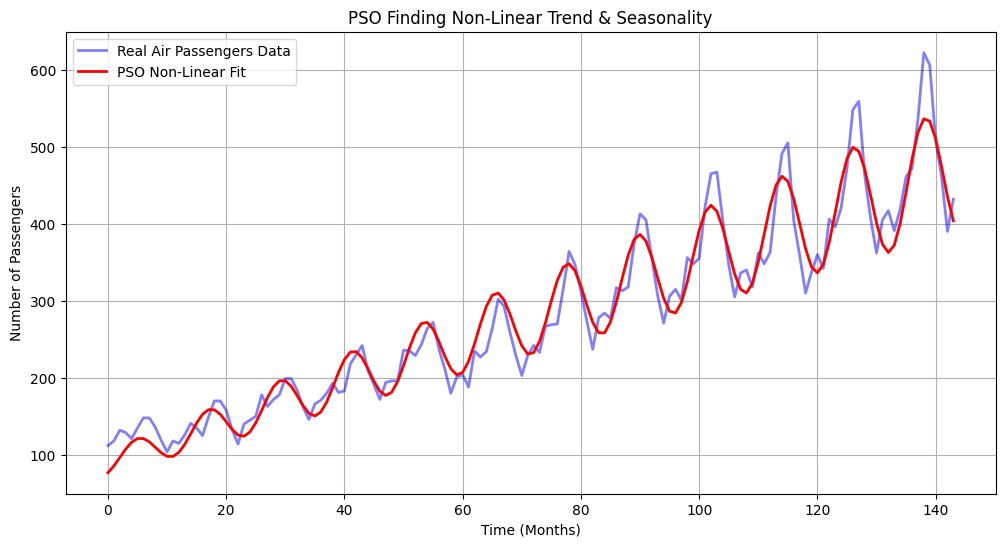

In [40]:
import numpy as np
import pandas as pd
import pyswarms as ps
import matplotlib.pyplot as plt

# --- 1. Load and Preprocess Data ---
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
y_true = df['Passengers'].values
t = np.arange(len(y_true))

# Normalize data (crucial for complex PSO problems)
y_max = np.max(y_true)
y_norm = y_true / y_max
t_max = np.max(t)
t_norm = t / t_max

# --- 2. Define Non-Linear MSE Objective Function ---
def mse_objective_nonlinear(particles):
    # particles shape: (n_particles, 5) -> columns are [m, c, A, B, D]
    n_particles = particles.shape[0]
    losses = []
    
    for i in range(n_particles):
        # Unpack the 5 parameters for this particle
        m, c, A, B, D = particles[i]
        
        # Calculate the non-linear prediction
        # Model: (Linear Trend) * (1 + Sinusoidal Seasonality)
        trend = m * t_norm + c
        seasonality = 1 + A * np.sin(B * t_norm + D)
        y_pred = trend * seasonality
        
        # Mean Squared Error
        mse = np.mean((y_norm - y_pred)**2)
        losses.append(mse)
    return np.array(losses)

# --- 3. Setup and Run PSO ---
# Define bounds for the 5 parameters based on domain knowledge.
# m, c: trend parameters (normalized, so between 0 and 1 is a good guess)
# A: amplitude is a fraction of the trend, e.g., 0 to 0.3
# B: Frequency. A 12-month cycle in 144 months means 12 cycles. 
#    Normalized time t goes 0->1. So B should be approx 2*pi * 12 ~= 75.
# D: Phase shift, 0 to 2*pi.
min_bound = np.array([0.0, 0.0, 0.0, 70.0, 0.0])
max_bound = np.array([1.0, 0.5, 0.3, 85.0, 2*np.pi])
bounds = (min_bound, max_bound)

# Increase particles and iterations for this harder problem
options = {'c1': 0.5, 'c2': 0.5, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=5, options=options, bounds=bounds)

# Perform optimization
print("Running PSO for non-linear fit... this may take a moment.")
cost, pos = optimizer.optimize(mse_objective_nonlinear, iters=300, verbose=False)

# --- 4. Result & Visualization ---
m_best, c_best, A_best, B_best, D_best = pos

# Calculate the final curve on the normalized scale
trend_norm = m_best * t_norm + c_best
seasonality_norm = 1 + A_best * np.sin(B_best * t_norm + D_best)
y_fit_norm = trend_norm * seasonality_norm

# Convert back to original scale for plotting
y_fit_real = y_fit_norm * y_max

print(f"\nBest Parameters Found:")
print(f"Trend: m={m_best:.4f}, c={c_best:.4f}")
print(f"Seasonality: A={A_best:.4f}, B={B_best:.4f}, D={D_best:.4f}")
print(f"Final MSE Loss (Normalized): {cost:.6f}")

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(t, y_true, label='Real Air Passengers Data', color='blue', alpha=0.5, linewidth=2)
plt.plot(t, y_fit_real, label='PSO Non-Linear Fit', color='red', linewidth=2)
plt.title('PSO Finding Non-Linear Trend & Seasonality')
plt.xlabel('Time (Months)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

### 4. Optimization using NiaPy
This cell explores the `niapy` library as an alternative to `pyswarms`. It sets up a task to minimize the Sphere function and runs the `ParticleSwarmOptimization` algorithm provided by the package.

In [35]:

from niapy.algorithms.basic import ParticleSwarmOptimization
from niapy.task import Task
from niapy.problems import Sphere

# Define a task: Minimize Sphere function with 3 dimensions
task = Task(problem=Sphere(dimension=3), max_iters=100)

# Initialize NiaPy PSO algorithm
algo = ParticleSwarmOptimization(population_size=30, c1=2.0, c2=2.0, w=0.7)

# Run optimization
best_score, best_solution = algo.run(task)

print(f"NiaPy Best Solution: {best_solution}")
print(f"NiaPy Best Score: {best_score}")

NiaPy Best Solution: 0.04074463725453693
NiaPy Best Score: [ 0.1826797  -0.05605759 -0.06504084]


### 5. Feature Selection using Binary PSO
This cell applies Binary PSO for feature selection on the Breast Cancer dataset. The objective is to find a subset of features that maximizes the accuracy of a Logistic Regression classifier (by minimizing $1 - \text{accuracy}$).

In [36]:
import numpy as np
import pyswarms as ps
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# --- 1. Load Medical Data (Breast Cancer) ---
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 2. Define Feature Selection Objective ---
def feature_selection_objective(x):
    # x is a binary mask (1 = select, 0 = ignore)
    n_particles = x.shape[0]
    j = []
    for i in range(n_particles):
        features = x[i]
        
        # Penalty if no features are selected
        if np.count_nonzero(features) == 0:
            j.append(1.0)
            continue
            
        # Select specific columns from dataset
        X_tr_sub = X_train[:, features == 1]
        X_te_sub = X_test[:, features == 1]
        
        # Train a quick classifier
        clf = LogisticRegression(solver='liblinear')
        clf.fit(X_tr_sub, y_train)
        score = clf.score(X_te_sub, y_test)
        
        # We want to maximize accuracy, so we minimize (1 - accuracy)
        j.append(1.0 - score)
    return np.array(j)

# --- 3. Run Binary PSO ---
# FIXED: changed k to 5 (must be less than n_particles which is 15)
options_bin = {'c1': 0.5, 'c2': 0.5, 'w':0.9, 'k': 5, 'p':2}
optimizer_fs = ps.discrete.BinaryPSO(n_particles=15, dimensions=30, options=options_bin)

cost_fs, pos_fs = optimizer_fs.optimize(feature_selection_objective, iters=20, verbose=False)

selected_features = np.where(pos_fs == 1)[0]
print(f"Total Features: {X.shape[1]}")
print(f"Selected Features ({len(selected_features)}): {selected_features}")
print(f"Best Accuracy Achieved: {(1 - cost_fs):.2%}")

Total Features: 30
Selected Features (13): [ 0  2  3 11 12 14 20 22 23 24 25 27 29]
Best Accuracy Achieved: 99.42%


### 6. Data Clustering using PSO
This cell uses PSO to perform clustering on the Breast Cancer dataset. The particles represent the coordinates of cluster centroids, and the objective is to minimize the Sum of Squared Errors (SSE) between data points and their nearest centroids.

In [41]:
import numpy as np
import pyswarms as ps
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin_min

# --- 1. Load and SCALE Data (Crucial Step) ---
data = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data) # Mean=0, Variance=1

n_clusters = 2
n_features = X_scaled.shape[1]

# --- 2. Define Objective ---
def clustering_objective(particles):
    costs = []
    for particle in particles:
        centroids = particle.reshape(n_clusters, n_features)
        # Calculate distances on SCALED data
        _, dists = pairwise_distances_argmin_min(X_scaled, centroids)
        costs.append(np.sum(dists**2))
    return np.array(costs)

# --- 3. Run PSO on Scaled Data ---
# Bounds are now much smaller (approx -3 to 3 for standard normal data)
min_bound = -3.0 * np.ones(n_clusters * n_features)
max_bound = 3.0 * np.ones(n_clusters * n_features)
bounds = (min_bound, max_bound)

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=30, dimensions=n_clusters*n_features, 
                                    options=options, bounds=bounds)

cost, pos = optimizer.optimize(clustering_objective, iters=50, verbose=False)

print(f" Scaled SSE: {cost:.2f}") 

New Scaled SSE: 16656.27
